In [ ]:
from countryinfo import CountryInfo
import itertools
import geopy.distance
import pickle
import os
from sko.GA import GA_TSP
import numpy as np
import matplotlib.pyplot as plt
from python_tsp.heuristics import solve_tsp_simulated_annealing
import plotly.graph_objects as go

In [ ]:
%pip install scikit-opt
%pip install countryinfo
%pip install python_tsp
%pip install plotly mapbox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 12.0 MB/s eta 0:00:00


In [ ]:

# Get a list of all country names
country_names = CountryInfo().all()
while True:
  userinput_startingpoint = input("Select santas starting point: ")
  if userinput_startingpoint in country_names:
      verified_startingpoint = userinput_startingpoint
      print("Setting santa's starting point to", verified_startingpoint)
      break
  else:
      print("That country doesn't exist, (try ex. finland)")

# Create a dictionary to store the capital city coordinates for each country
capitals = {}

for name in country_names:
    # Create a CountryInfo object for each country
    country = CountryInfo(name)

    # Get the country info
    info = country.info()

    # Get the capital city coordinates
    capital_coords = info.get('capital_latlng')

    if capital_coords:  # Check if the coordinates are available
        capitals[name] = capital_coords

# Define a function to calculate the distance between two cities
def calc_distance(city1, city2):
    return geopy.distance.distance(city1, city2).km


# Convert the capitals dictionary to a distance matrix
num_cities = len(capitals)
dist_matrix = np.zeros((num_cities, num_cities))
for i, city1 in enumerate(capitals.values()):
    for j, city2 in enumerate(capitals.values()):
        dist_matrix[i, j] = calc_distance(city1, city2)




Select santas starting point: germany
Setting santa's starting point to  germany


## GA (This takes a while to get good results, around 15-20k iterations)

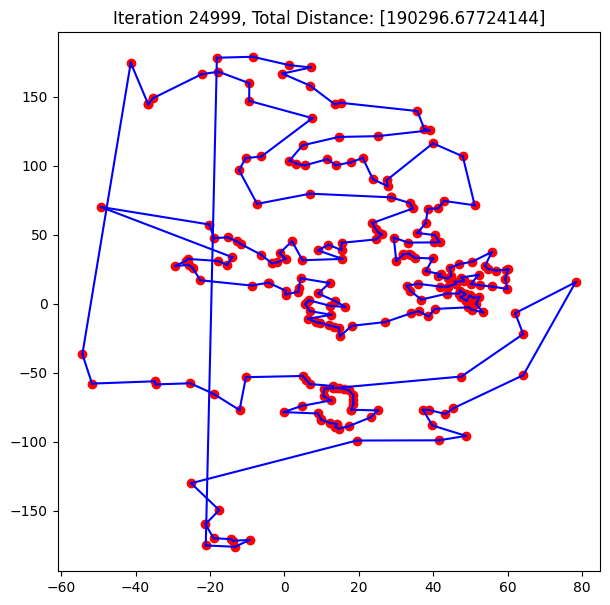

Best order: ['germany', 'denmark', 'norway', 'sweden', 'finland', 'estonia', 'latvia', 'lithuania', 'belarus', 'russia', 'ukraine', 'moldova', 'romania', 'serbia', 'bosnia and herzegovina', 'albania', 'republic of macedonia', 'greece', 'turkey', 'cyprus', 'lebanon', 'syria', 'jordan', 'israel', 'egypt', 'kuwait', 'iraq', 'armenia', 'georgia', 'azerbaijan', 'iran', 'turkmenistan', 'tajikistan', 'uzbekistan', 'kyrgyzstan', 'kazakhstan', 'mongolia', 'china', 'bhutan', 'nepal', 'bangladesh', 'vietnam', 'laos', 'thailand', 'cambodia', 'cayman islands', 'malaysia', 'singapore', 'brunei', 'philippines', 'taiwan', 'north korea', 'south korea', 'japan', 'northern mariana islands', 'guam', 'federated states of micronesia', 'nauru', 'marshall islands', 'kiribati', 'tuvalu', 'fiji', 'tonga', 'wallis and futuna', 'tokelau', 'samoa', 'american samoa', 'niue', 'cook islands', 'french polynesia', 'pitcairn islands', 'mexico', 'anguilla', 'dominica', 'isle of man', 'saint helena', 'united states', 'ber

In [ ]:
# Define the TSP objective function
def tsp_objective_function(order):
    return sum(dist_matrix[order[i - 1], order[i]] for i in range(num_cities))

def plot_route(best_order, capitals, city_names, i, best_distance):
    plt.figure(figsize=(7, 7))
    for j in range(num_cities - 1):
        city1 = city_names[best_order[j]]
        city2 = city_names[best_order[j + 1]]
        plt.plot([capitals[city1][0], capitals[city2][0]],
                [capitals[city1][1], capitals[city2][1]], 'b-')
    city1 = city_names[best_order[-1]]
    city2 = city_names[best_order[0]]
    plt.plot([capitals[city1][0], capitals[city2][0]],
            [capitals[city1][1], capitals[city2][1]], 'b-')
    plt.scatter([capital[0] for capital in capitals.values()],
                [capital[1] for capital in capitals.values()], c='r')
    plt.title(f"Iteration {i}, Total Distance: {best_distance}")
    plt.show()

# Create a GA_TSP object
ga_tsp = GA_TSP(func=tsp_objective_function, n_dim=num_cities, size_pop=200, max_iter=25000, prob_mut=1)


import matplotlib.pyplot as plt

checkpoint_file = 'checkpoint.pkl'

# Initialize a list to store the best distance at each iteration
best_distances = []

i = 0

# Load from checkpoint
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'rb') as f:
        i, ga_tsp.X, ga_tsp.Y, ga_tsp.FitV, ga_tsp.generation_best_X, ga_tsp.Chrom, ga_tsp.generation_best_Y, best_order, best_distances = pickle.load(f)
    i += 1  # Start from the next iteration

# Create a list of city names
city_names = list(capitals.keys())

# Run the GA algorithm with checkpointing and progress printouts
for i in range(i, ga_tsp.max_iter):
    best_order, best_distance = ga_tsp.run(1)  # Run for 1 iteration
    best_distances.append(best_distance)  # Append the best distance to the list

    # Print progress
    if i % 100 == 0:
        print(f"After {i} iterations, best distance is {best_distance}")

    if i % 100 == 0:
        # Save to checkpoint
        with open(checkpoint_file, 'wb') as f:
            pickle.dump((i, ga_tsp.X, ga_tsp.Y, ga_tsp.FitV, ga_tsp.generation_best_X, ga_tsp.Chrom, ga_tsp.generation_best_Y, best_order, best_distances), f)

        plot_route(best_order, capitals, city_names, i, best_distance)



# Convert the numpy array to a list
best_order_list = best_order.tolist()

# Find the index of the set starting point in the best order
start_index = best_order_list.index(city_names.index(verified_startingpoint))

# Rotate the best order so that it starts from the set starting point
rotated_order = best_order_list[start_index:] + best_order_list[:start_index]

plot_route(best_order, capitals, city_names, i, best_distance)

print('Best order:', [city_names[i] for i in rotated_order])
print('Best distance:', best_distance)




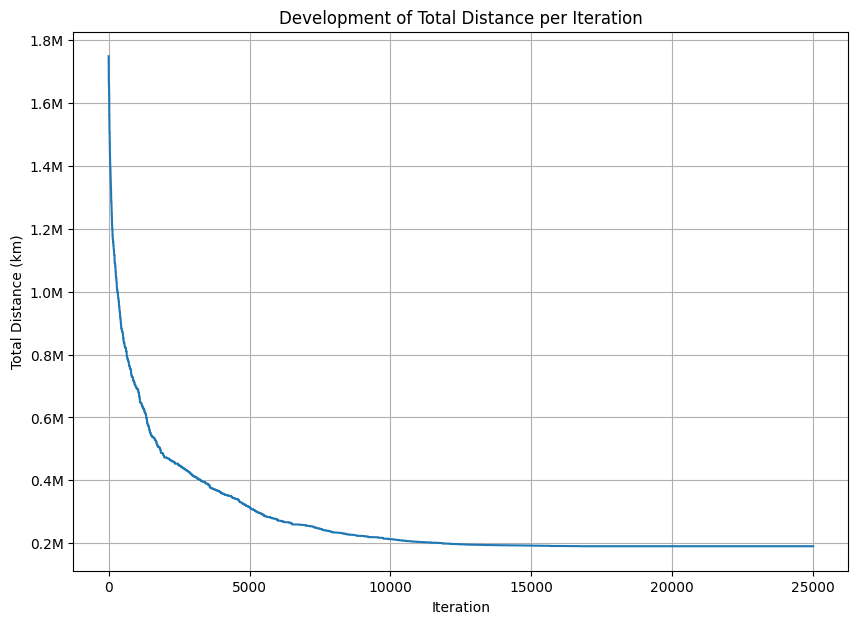

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    'The two args are the value and tick position'
    return '%1.1fM' % (x * 1e-6)

formatter = FuncFormatter(millions)

fig, ax = plt.subplots(figsize=(10, 7))
ax.yaxis.set_major_formatter(formatter)
plt.plot(best_distances)
plt.xlabel('Iteration')
plt.ylabel('Total Distance (km)')
plt.title('Development of Total Distance per Iteration')
plt.grid(True)
plt.show()

## Simulated Annealing (fast but quite inconsistant results)

The optimal tour is: ['germany', 'grenada', 'saint pierre and miquelon', 'liechtenstein', 'slovenia', 'croatia', 'italy', 'san marino', 'monaco', 'switzerland', 'jersey', 'réunion', 'france', 'luxembourg', 'belgium', 'netherlands', 'denmark', 'norway', 'sweden', 'finland', 'estonia', 'latvia', 'lithuania', 'poland', 'belarus', 'russia', 'ukraine', 'moldova', 'georgia', 'armenia', 'azerbaijan', 'turkmenistan', 'iran', 'kuwait', 'iraq', 'saudi arabia', 'yemen', 'qatar', 'bahrain', 'united arab emirates', 'oman', 'sri lanka', 'british indian ocean territory', 'mauritius', 'madagascar', 'bulgaria', 'mayotte', 'comoros', 'kenya', 'rwanda', 'burundi', 'central african republic', 'chad', 'sudan', 'eritrea', 'djibouti', 'somalia', 'ethiopia', 'south sudan', 'uganda', 'tanzania', 'malawi', 'zambia', 'zimbabwe', 'mozambique', 'swaziland', 'lesotho', 'south africa', 'botswana', 'namibia', 'angola', 'republic of the congo', 'democratic republic of the congo', 'gabon', 'são tomé and príncipe', 'cam

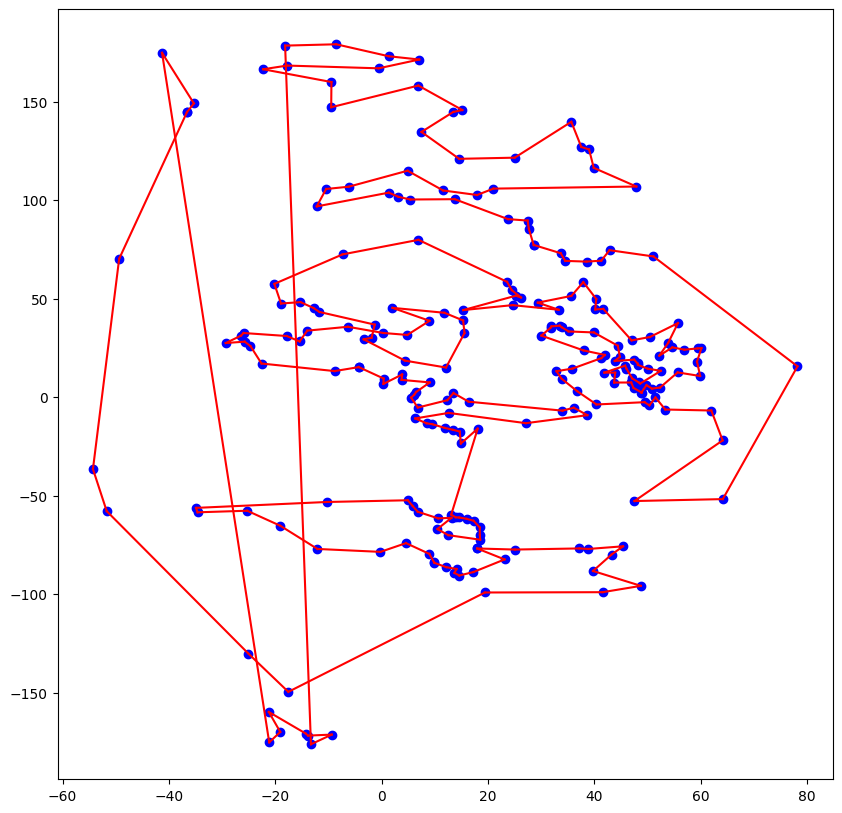

In [ ]:
permutation, distance = solve_tsp_simulated_annealing(dist_matrix)

route = [city_names[i] for i in permutation]

# Find the index of 'finland' in the best order
start_index = route.index(verified_startingpoint)

# Rotate the best order so that it starts from the set starting point
rotated_order = route[start_index:] + route[:start_index]

print("The optimal tour is:", rotated_order)
print("The total distance is:", distance)

# Create a new list of tuples
route_with_coordinates = [(country, capitals[country]) for country in route if country in capitals]

plt.figure(figsize=(10, 10))

# Plot the capitals
for country, coords in capitals.items():
    plt.plot(coords[0], coords[1], 'bo')

# Plot the route
for i in range(len(route_with_coordinates) - 1):
    country1, coords1 = route_with_coordinates[i]
    country2, coords2 = route_with_coordinates[i + 1]
    plt.plot([coords1[0], coords2[0]], [coords1[1], coords2[1]], 'r-')

# Connect the last capital with the first one to complete the route
country1, coords1 = route_with_coordinates[-1]
country2, coords2 = route_with_coordinates[0]
plt.plot([coords1[0], coords2[0]], [coords1[1], coords2[1]], 'r-')

plt.show()

In [ ]:
# A sick visualization
fig = go.Figure(data=go.Scattergeo(
    lon = [coord[1] for country, coord in capitals.items()],
    lat = [coord[0] for country, coord in capitals.items()],
    mode = 'markers',
    marker = dict(size = 10, color = 'green'),
    text = list(capitals.keys()),
    hoverinfo = 'text',
))

# Add lines for the route
for i in range(len(route_with_coordinates) - 1):
    fig.add_trace(go.Scattergeo(
        lon = [route_with_coordinates[i][1][1], route_with_coordinates[i + 1][1][1]],
        lat = [route_with_coordinates[i][1][0], route_with_coordinates[i + 1][1][0]],
        mode = 'lines',
        line = dict(width = 2, color = 'red'),
    ))

# Connect the last capital with the first one to complete the route
fig.add_trace(go.Scattergeo(
    lon = [route_with_coordinates[-1][1][1], route_with_coordinates[0][1][1]],
    lat = [route_with_coordinates[-1][1][0], route_with_coordinates[0][1][0]],
    mode = 'lines',
    line = dict(width = 2, color = 'red'),
))

# Update the layout of the plot
fig.update_layout(
    title_text = 'Route',
    showlegend = False,
    geo = dict(
        showland = True,
        showcountries = True,
        showocean = True,
        countrywidth = 0.5,
        landcolor = 'rgb(1, 1, 10)',
        lakecolor = 'rgb(255, 255, 255)',
        oceancolor = 'rgb(255, 255, 255)',
        projection = dict(
            type = 'natural earth'
        ),
    ),
    autosize = False,
    width=1200,
    height=600,

)

fig.show()